In [8]:
import numpy as np
import pandas as pd
from matplotlib.figure import Figure
import matplotlib.pyplot as plt

In [2]:
flax_data = {
    'price': [33, 32, 31, 30, 29, 28, 27],
    'bid_vol': [0, 0, 0, 30000, 5000, 12000, 28000],
    'ask_vol': [30000, 20000, 20000, 0, 0, 40000, 0]
}
flax_df = pd.DataFrame(flax_data).set_index("price")
flax_df["cumulative_bid_vol"] = flax_df["bid_vol"].cumsum()
flax_df["cumulative_ask_vol"] = flax_df.loc[::-1, "ask_vol"].cumsum()[::-1]
flax_df

,bid_vol,ask_vol,cumulative_bid_vol,cumulative_ask_vol
price,,,,
33,0,30000,0,110000
32,0,20000,0,80000
31,0,20000,0,60000
30,30000,0,30000,40000
29,5000,0,35000,40000
28,12000,40000,47000,40000
27,28000,0,75000,0


In [3]:
mushroom_data = {
    'price': [20, 19, 18, 17, 16, 15, 14, 13, 12],
    'bid_vol': [43000, 17000, 6000, 5000, 10000, 5000, 10000, 7000, 0],
    'ask_vol': [0, 12000, 10000, 0, 5000, 6000, 35000, 25000, 20000]
}
mush_df = pd.DataFrame(mushroom_data).set_index('price')
mush_df["cumulative_bid_vol"] = mush_df["bid_vol"].cumsum()
mush_df["cumulative_ask_vol"] = mush_df["ask_vol"].loc[::-1].cumsum().loc[::-1]
mush_df

,bid_vol,ask_vol,cumulative_bid_vol,cumulative_ask_vol
price,,,,
20,43000,0,43000,113000
19,17000,12000,60000,113000
18,6000,10000,66000,101000
17,5000,0,71000,91000
16,10000,5000,81000,91000
15,5000,6000,86000,86000
14,10000,35000,96000,80000
13,7000,25000,103000,45000
12,0,20000,103000,20000


## Analysis for Dryland Flax
The clearing price is set as max[min(cum_bid, cum_ask)]. <br>
In other words the clearing price at which the maximum volume is traded <br>
Eligible bids: bids where bid_price >= clearing_price <br>
Eligible asks: asks where ask_price <= clearing_price

In [5]:
def find_clearing_price(df):
    clearing_price = 0
    best_clearing_vol = 0
    for p in df.index:
        clearing_vol = min(df["cumulative_bid_vol"][p], df["cumulative_ask_vol"][p])
        if clearing_vol > best_clearing_vol:
            # market clears more volume, does not matter if price is lower
            # this becomes the new clearing price as the exchange
            # simply chooses the price that yields the most traded volume
            # only tie-breaking is done based by price
            best_clearing_vol = clearing_vol
            clearing_price = p

        elif clearing_vol == best_clearing_vol and p > clearing_price:
            # best_clearing_vol remains the same
            clearing_price = p # is updated due to breaking ties by choosing the higher price

        else:
            # we did not clear more at this clearing price so we continue 
            continue

    print(f"Initial clearing price: {clearing_price}")
    print(f"Initial clearing vol: {best_clearing_vol}")

find_clearing_price(flax_df)

Initial clearing price: 28
Initial clearing vol: 40000


Now we want to find a state of the world where
1. eligible_asks_vol > eligible_bids_vol
2. eligible_asks >= 40 000
3. clearing_price < 30
<br>

If any such states exist, our profit will be: <br>
(eligible_asks_vol - eligible_bids_vol) * (30 - resulting_clearing_price)

Optimal order: BUY 5000 @ 29


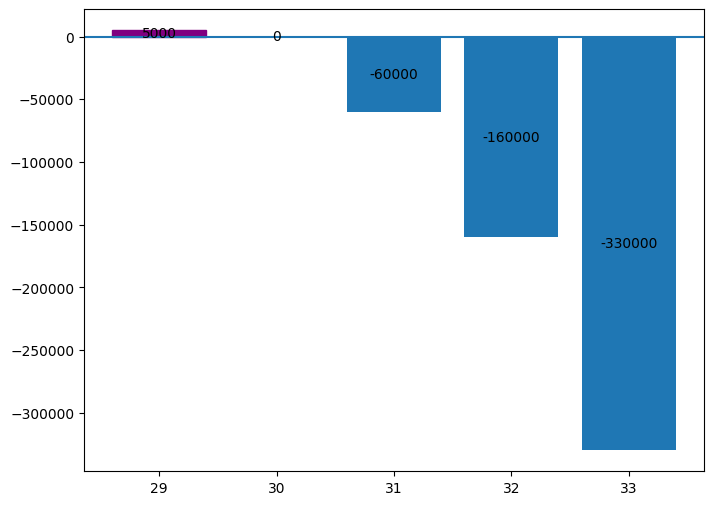

In [11]:
def find_optimal_order_flax():
    ### criteria 1 & 2
    mask_vol = (flax_df["cumulative_ask_vol"] > flax_df["cumulative_bid_vol"]) & (flax_df["cumulative_ask_vol"] >= 40_000)
    better_states_of_the_world = flax_df[mask_vol]

    max_profit = 0
    optimal_order_price = 0
    optimal_order_vol = 0
    states_x = []
    states_y = []
    for p in better_states_of_the_world.index:
        ask_vol = better_states_of_the_world["cumulative_ask_vol"][p]
        bid_vol = better_states_of_the_world["cumulative_bid_vol"][p]
        profit_in_this_state = (ask_vol - bid_vol) * (30 - p)
        states_x.append(p)
        states_y.append(profit_in_this_state)
        if profit_in_this_state > max_profit:
            max_profit = profit_in_this_state
            ## our best bid is p (the clearing price) as it is the lowest bid that satisfies bid >= clearing_price
            optimal_order_price = p
            ## we make money on every lot, so we want to take all quantity available
            optimal_order_vol = ask_vol - bid_vol


    fig, ax = plt.subplots(figsize=(8, 6))
    states = zip(states_x, states_y)
    bars = ax.bar(states_x, states_y)
    ax.bar_label(bars, label_type='center')
    ax.axhline(y=0)
    bars[list(bars.datavalues).index(max(bars.datavalues))].set_color("purple")    
    print(f"Optimal order: BUY {optimal_order_vol} @ {optimal_order_price}")
    
    plt.show()

find_optimal_order_flax()

## Analysis for Ember Mushrooms

In [12]:
find_clearing_price(df=mush_df)

Initial clearing price: 15
Initial clearing vol: 86000


We want to find a state of the world where
1. eligible_asks_vol > eligible_bids_vol
2. eligible_asks >= 86 000
3. clearing_price < 20

Optimal order: BUY 35000 @ 18


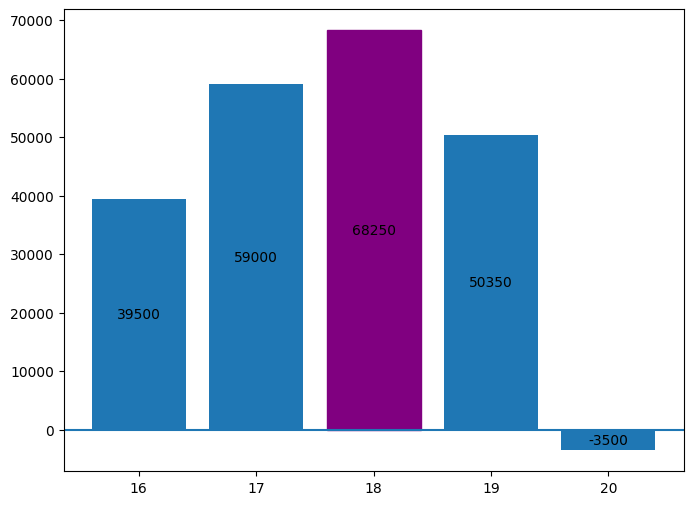

In [13]:
def find_optimal_order_mush():
    ### criteria 1 & 2
    mask_vol = (mush_df["cumulative_ask_vol"] > mush_df["cumulative_bid_vol"]) & (mush_df["cumulative_ask_vol"] >= 86_000)
    better_states_of_the_world = mush_df[mask_vol]

    max_profit = 0
    optimal_order_price = 0
    optimal_order_vol = 0
    states_x = []
    states_y = []

    for p in better_states_of_the_world.index:
        ask_vol = better_states_of_the_world["cumulative_ask_vol"][p]
        bid_vol = better_states_of_the_world["cumulative_bid_vol"][p]
        ## we have trading fees
        profit_in_this_state = (ask_vol - bid_vol) * (20 - p) - (ask_vol - bid_vol)*0.05
        states_x.append(p)
        states_y.append(profit_in_this_state)
        if profit_in_this_state > max_profit:
            max_profit = profit_in_this_state
            ## our best bid is p (the clearing price) as it is the lowest bid that satisfies bid >= clearing_price
            optimal_order_price = p
            ## we make money on every lot, so we want to take all quantity available
            optimal_order_vol = ask_vol - bid_vol


    fig = Figure(figsize=(8, 6))
    ax = fig.subplots()
    states = zip(states_x, states_y)
    bars = ax.bar(states_x, states_y)

    ax.bar_label(bars, label_type='center')
    ax.axhline(y=0)

    print(f"Optimal order: BUY {optimal_order_vol} @ {optimal_order_price}")
    bars[list(bars.datavalues).index(max(bars.datavalues))].set_color("purple")
    return fig

find_optimal_order_mush()